# Bab 1: Exploratory Data Analysis

Notebook ini adalah rangkuman dari Bab 1.

Dataset yang dipakai di sini sama persis dengan yang dipakai di buku, Tiap bagian pakai dataset yang paling sesuai dengan contoh di buku:

*   `state.csv`: populasi dan tingkat pembunuhan tiap negara bagian AS
*   `dfw_ailine.csv`: persentase penyebab delay penerbangan di Dallas/Fort Worth
*   `sp500_data.csv.gz` dan `sp500_sectors.csv` — return harian saham-saham S&P 500
*   `kc_tax.csv.gz` — nilai pajak properti dan luas bangunan di King County
*   `lc_loans.csv` — status dan grade pinjaman dari Lending Club
*   `airline_stats.csv` — persentase delay per maskapai



In [3]:
!pip install wquantiles

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import wquantiles as wq

sns.set_style("whitegrid")
pd.set_option("display.precision", 3)

BASE = "https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/"
state = pd.read_csv(BASE + "state.csv")
state.head()

,State,Population,Murder.Rate,Abbreviation
0,Alabama,4779736,5.7,AL
1,Alaska,710231,5.6,AK
2,Arizona,6392017,4.7,AZ
3,Arkansas,2915918,5.6,AR
4,California,37253956,4.4,CA


## 1. Elements of Structured Data

Sebelum mengolah data, penting untuk tahu jenis tiap kolom, karena jenis data menentukan analisis dan visualisasi apa yang masuk akal.

Ada dua kelompok besar:

- **Numerik**: bisa *kontinu* (nilainya bisa berapa saja dalam suatu rentang, misalnya `Murder.Rate`) atau *diskrit* (hanya bilangan bulat, misalnya `Population`).
- **Kategorikal**: punya sejumlah kategori tetap. Kalau kategorinya cuma dua, disebut *biner*. Kalau kategorinya punya urutan alami, disebut *ordinal*. Di dataset `state`, kolom `State` dan `Abbreviation` termasuk kategorikal nominal, karena tidak punya urutan alami.

In [7]:
state.dtypes

,0
State,object
Population,int64
Murder.Rate,float64
Abbreviation,object


In [8]:
state["State"] = state["State"].astype("category")
state["Abbreviation"] = state["Abbreviation"].astype("category")
state.dtypes

,0
State,category
Population,int64
Murder.Rate,float64
Abbreviation,category


## 2. Rectangular Data

Dua istilah yang sering dipakai:

- **Feature**: kolom, variabel yang jadi input analisis.
- **Index**: penomoran baris. Secara default pandas membuat index integer otomatis, tapi kolom lain juga bisa dijadikan index kalau lebih bermakna.

Dataset `state` ini contoh rectangular data yang paling sederhana: setiap baris satu negara bagian, dengan kolom populasi, tingkat pembunuhan, dan singkatan namanya.

In [9]:
print("Jumlah baris, kolom:", state.shape)
state.info()

Jumlah baris, kolom: (50, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   State         50 non-null     category
 1   Population    50 non-null     int64   
 2   Murder.Rate   50 non-null     float64 
 3   Abbreviation  50 non-null     category
dtypes: category(2), float64(1), int64(1)
memory usage: 5.9 KB


Data yang tidak berbentuk tabel rapi seperti ini disebut *nonrectangular*, contohnya data time series, data graf/jaringan (relasi antar entitas), atau data spasial.

## 3. Estimates of Location

Langkah pertama saat melihat variabel numerik biasanya adalah mencari nilai tengah atau nilai tipikalnya, ini yang disebut *estimate of location*.

**Mean (rata-rata)** adalah jumlah semua nilai dibagi banyaknya data. Gampang dihitung, tapi sangat sensitif terhadap outlier atau data yang miring (skewed).

**Median** adalah nilai tengah setelah data diurutkan. Median jauh lebih tahan (robust) terhadap outlier dibanding mean, karena hanya bergantung pada posisi, bukan besar nilai ekstrem.

**Trimmed mean** adalah jalan tengah: buang sekian persen nilai terkecil dan terbesar, baru hitung rata-rata dari sisanya. Ini mengurangi pengaruh outlier tanpa membuang informasi sebanyak median.

**Weighted mean** dipakai kalau tidak semua observasi punya bobot yang sama.

In [10]:
pop = state["Population"]

mean_val = pop.mean()
median_val = pop.median()
trimmed_mean_val = stats.trim_mean(pop, 0.1)  # buang 10% data terkecil & terbesar dari tiap sisi

print(f"Mean population         : {mean_val:,.0f}")
print(f"Trimmed mean population : {trimmed_mean_val:,.0f}")
print(f"Median population       : {median_val:,.0f}")

Mean population         : 6,162,876
Trimmed mean population : 4,783,697
Median population       : 4,436,370


Mean jauh lebih besar dari median dan trimmed mean, karena ditarik oleh beberapa negara bagian dengan populasi sangat besar seperti California dan Texas. Trimmed mean mendekati median justru karena dua negara bagian paling ekstrem sudah dibuang sebelum dirata-rata.

In [11]:
state.nlargest(3, "Population")[["State", "Population"]]

,State,Population
4,California,37253956
42,Texas,25145561
31,New York,19378102


Untuk **Murder.Rate**, buku memberi contoh yang lebih menarik: menghitung rata-rata tingkat pembunuhan, tapi dengan bobot populasi tiap negara bagian. Alasannya, negara bagian dengan penduduk sedikit tidak seharusnya punya pengaruh sebesar negara bagian dengan penduduk jutaan saat menghitung rata-rata nasional.

In [12]:
simple_mean_murder = state["Murder.Rate"].mean()
weighted_mean_murder = np.average(state["Murder.Rate"], weights=state["Population"])
weighted_median_murder = wq.median(state["Murder.Rate"], weights=state["Population"])

print(f"Mean murder rate (tanpa bobot)   : {simple_mean_murder:.3f}")
print(f"Weighted mean murder rate        : {weighted_mean_murder:.3f}")
print(f"Weighted median murder rate      : {weighted_median_murder:.3f}")

Mean murder rate (tanpa bobot)   : 4.066
Weighted mean murder rate        : 4.446
Weighted median murder rate      : 4.400


Weighted mean sedikit lebih rendah dibanding mean biasa, karena beberapa negara bagian besar seperti California punya tingkat pembunuhan yang relatif rendah, dan bobot populasinya menarik rata-rata nasional ke arah situ.

## 4. Estimates of Variability

Nilai tengah saja belum cukup. Dua dataset bisa punya mean yang sama tapi sebaran datanya jauh berbeda, jadi kita juga perlu mengukur *variabilitas*, seberapa tersebar data itu.

- **Standard deviation (simpangan baku)** dan **variance**: mengukur sebaran berdasarkan jarak kuadrat tiap titik data ke mean. Karena dikuadratkan, outlier berpengaruh besar di sini.
- **Mean Absolute Deviation (MAD)** dan **Median Absolute Deviation dari median**: alternatif yang lebih robust, karena tidak mengkuadratkan selisihnya.
- **Range**: selisih nilai maksimum dan minimum, gampang dihitung tapi sangat rentan terhadap outlier.
- **Percentile-based**: seperti **IQR (Interquartile Range)**, selisih antara persentil 75 dan persentil 25. Ini yang jadi dasar boxplot.

In [13]:
std_val = pop.std()
var_val = pop.var()
mad_val = stats.median_abs_deviation(pop, scale="normal")  # skala 'normal' biar sebanding dengan std
range_val = pop.max() - pop.min()
iqr_val = pop.quantile(0.75) - pop.quantile(0.25)

print(f"Standard deviation population : {std_val:,.0f}")
print(f"Variance population           : {var_val:,.0f}")
print(f"MAD population (robust)       : {mad_val:,.0f}")
print(f"Range population              : {range_val:,.0f}")
print(f"IQR population                : {iqr_val:,.0f}")

Standard deviation population : 6,848,235
Variance population           : 46,898,327,373,394
MAD population (robust)       : 3,849,876
Range population              : 36,690,330
IQR population                : 4,847,308


Standard deviation jauh lebih besar dari MAD, walau keduanya sama-sama mengukur sebaran dalam satuan yang sebanding. Selisih ini datang dari populasi California dan Texas yang jauh di atas negara bagian lain, dan itu memengaruhi std dev jauh lebih keras dibanding MAD karena std dev melibatkan kuadrat selisih.

## 5. Exploring the Data Distribution

Setelah tahu nilai tengah dan sebarannya, langkah berikutnya adalah melihat bentuk distribusinya secara keseluruhan: apakah simetris, miring ke satu sisi, punya banyak puncak, dan sebagainya. Tiga alat utama untuk ini adalah boxplot, histogram, dan density plot.

**Boxplot** menampilkan median, kuartil 1 dan 3 (kotaknya), serta whisker yang biasanya menjangkau hingga 1.5 x IQR dari kotak. Titik-titik di luar itu dianggap potensi outlier.

**Histogram** membagi rentang data ke beberapa *bin* dan menghitung berapa banyak data di tiap bin.

**Density plot** pada dasarnya versi halus (smoothed) dari histogram, dihitung dengan kernel density estimation, dan tidak bergantung pada pemilihan lebar bin.

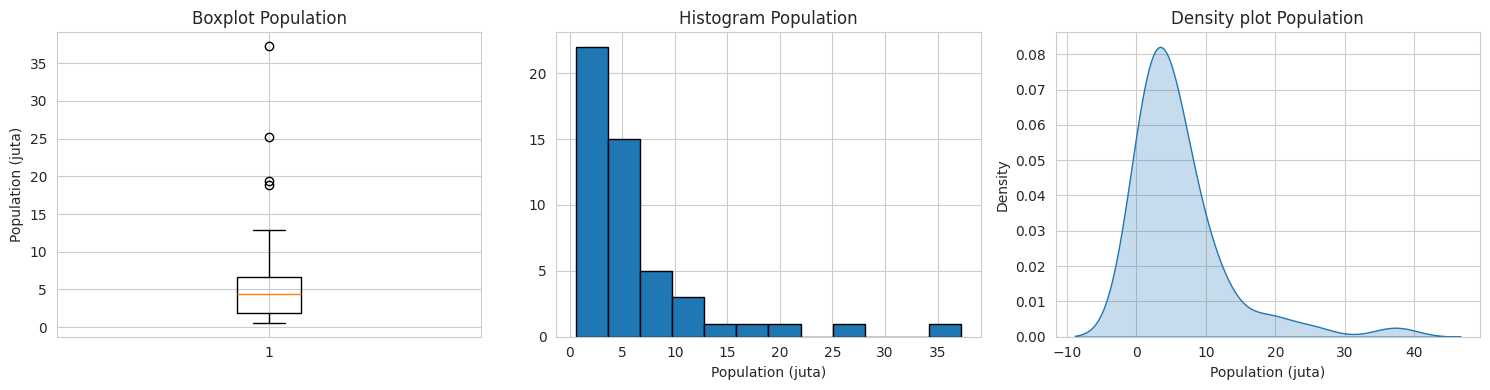

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].boxplot(pop / 1_000_000, vert=True)
axes[0].set_title("Boxplot Population")
axes[0].set_ylabel("Population (juta)")

axes[1].hist(pop / 1_000_000, bins=12, edgecolor="black")
axes[1].set_title("Histogram Population")
axes[1].set_xlabel("Population (juta)")

sns.kdeplot(pop / 1_000_000, ax=axes[2], fill=True)
axes[2].set_title("Density plot Population")
axes[2].set_xlabel("Population (juta)")

plt.tight_layout()
plt.show()

Ketiganya menampilkan hal yang konsisten: sebagian besar negara bagian punya populasi di bawah 10 juta, dan sisanya (California, Texas, dst.) muncul sebagai ekor panjang ke kanan, yang juga tampak sebagai titik-titik di atas whisker pada boxplot.

In [15]:
percentiles = pop.quantile([0.05, 0.25, 0.5, 0.75, 0.95])
percentiles

,Population
0.05,6.895e+05
0.25,1.833e+06
0.50,4.436e+06
0.75,6.680e+06
0.95,1.912e+07


## 6. Exploring Binary and Categorical Data

Untuk data kategorikal, konsep "nilai tengah" versi numerik seperti mean tidak berlaku langsung. Yang lebih relevan adalah:

- **Mode**: kategori yang paling sering muncul.
- **Expected value**: rata-rata tertimbang, tiap kategori dikalikan nilai/probabilitasnya.
- **Tabel frekuensi dan bar chart**: cara paling langsung melihat proporsi tiap kategori.

Contoh dari buku memakai data delay penerbangan di bandara Dallas/Fort Worth, dipecah menurut penyebabnya (cuaca, keamanan, ATC, dan sebagainya).

In [16]:
dfw = pd.read_csv(BASE + "dfw_airline.csv")
dfw

,Carrier,ATC,Weather,Security,Inbound
0,64263.16,84856.5,11235.42,343.15,118427.82


In [17]:
dfw_prop = 100 * dfw.iloc[0] / dfw.iloc[0].sum()
dfw_prop = dfw_prop.sort_values(ascending=False)
dfw_prop

,0
Inbound,42.428
ATC,30.401
Carrier,23.023
Weather,4.025
Security,0.123


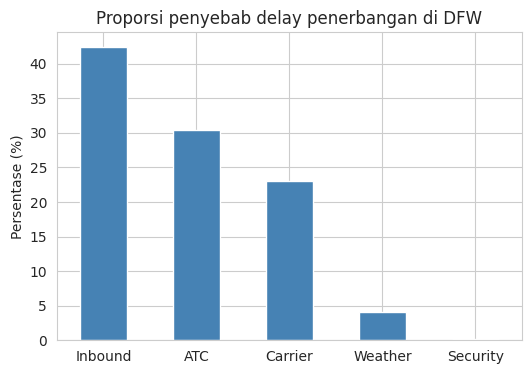

In [18]:
fig, ax = plt.subplots(figsize=(6, 4))
dfw_prop.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Proporsi penyebab delay penerbangan di DFW")
ax.set_ylabel("Persentase (%)")
plt.xticks(rotation=0)
plt.show()

Terlihat jelas bahwa penyebab terbesar delay adalah masalah operasional maskapai sendiri (Carrier), disusul faktor cuaca dan air traffic control. Bar chart seperti ini pas untuk data kategorikal, beda dengan histogram yang khusus untuk data numerik yang dikelompokkan ke bin.

## 7. Correlation

Korelasi mengukur seberapa kuat dan ke arah mana dua variabel numerik bergerak bersama. Ukuran paling umum adalah **koefisien korelasi Pearson**, nilainya antara -1 dan 1.

- Mendekati 1: berkorelasi positif kuat.
- Mendekati -1: berkorelasi negatif kuat.
- Mendekati 0: hampir tidak ada hubungan linear.

Buku memakai data return harian saham-saham S&P 500 untuk contoh ini, karena saham dalam sektor yang sama biasanya bergerak searah.

In [19]:
sp500_sectors = pd.read_csv(BASE + "sp500_sectors.csv")
sp500_data = pd.read_csv(BASE + "sp500_data.csv.gz", index_col=0)

# Ambil saham-saham dari sektor telekomunikasi sebagai contoh, seperti di buku
telecom_symbols = sp500_sectors.loc[sp500_sectors["sector"] == "telecommunications_services", "symbol"]
telecom = sp500_data.loc[:, sp500_data.columns.isin(telecom_symbols)]
telecom = telecom[telecom.index > "2012-07-01"]

corr_matrix = telecom.corr()
corr_matrix

,T,CTL,FTR,VZ,LVLT
T,1.000,0.475,0.328,0.678,0.279
CTL,0.475,1.000,0.420,0.417,0.287
FTR,0.328,0.420,1.000,0.287,0.260
VZ,0.678,0.417,0.287,1.000,0.242
LVLT,0.279,0.287,0.260,0.242,1.000


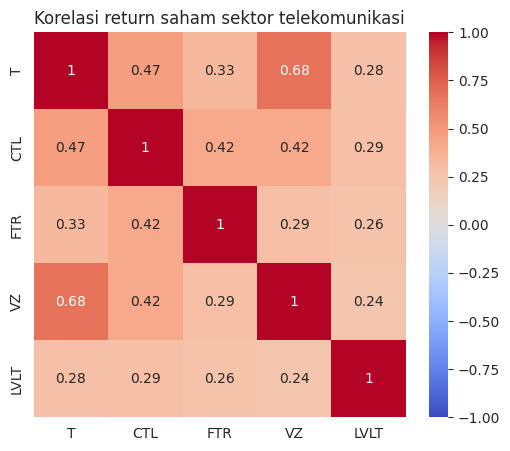

In [20]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Korelasi return saham sektor telekomunikasi")
plt.show()

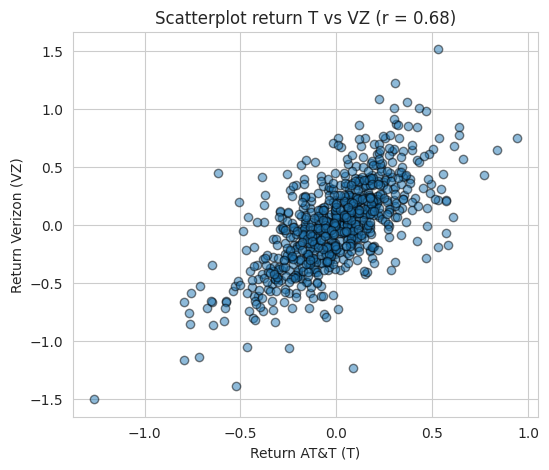

In [21]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(telecom["T"], telecom["VZ"], alpha=0.5, edgecolor="k")
ax.set_xlabel("Return AT&T (T)")
ax.set_ylabel("Return Verizon (VZ)")
ax.set_title(f"Scatterplot return T vs VZ (r = {corr_matrix.loc['T','VZ']:.2f})")
plt.show()

Return AT&T dan Verizon bergerak searah dengan cukup kuat, masuk akal karena keduanya sama-sama perusahaan telekomunikasi besar yang terpengaruh sentimen sektor yang mirip.

## 8. Explore Two oe More Variables

Untuk melihat hubungan antar lebih dari satu variabel, pendekatannya tergantung jenis datanya:

- **Numerik vs numerik dengan data sangat banyak**: scatterplot biasa jadi terlalu padat (overplotting), sehingga dipakai **hexbin plot** yang mengelompokkan titik-titik ke sel-sel heksagonal dan mewarnainya berdasarkan kepadatan.
- **Kategorikal vs kategorikal**: **contingency table**, tabel yang menghitung kombinasi kemunculan dua variabel kategorikal.
- **Kategorikal vs numerik**: boxplot berdampingan (satu boxplot per kategori) untuk membandingkan distribusi numerik antar kelompok.

In [22]:
kc_tax = pd.read_csv(BASE + "kc_tax.csv.gz")

# Buku membatasi data ke rentang wajar dulu, karena ada nilai ekstrem/pencilan
kc_tax0 = kc_tax.loc[
    (kc_tax["TaxAssessedValue"] < 750000)
    & (kc_tax["SqFtTotLiving"] > 100)
    & (kc_tax["SqFtTotLiving"] < 3500)
]
print(f"Jumlah baris setelah difilter: {len(kc_tax0):,}")
kc_tax0.head()

Jumlah baris setelah difilter: 432,693


,TaxAssessedValue,SqFtTotLiving,ZipCode
1,206000.0,1870,98002.0
2,303000.0,1530,98166.0
3,361000.0,2000,98108.0
4,459000.0,3150,98108.0
5,223000.0,1570,98032.0


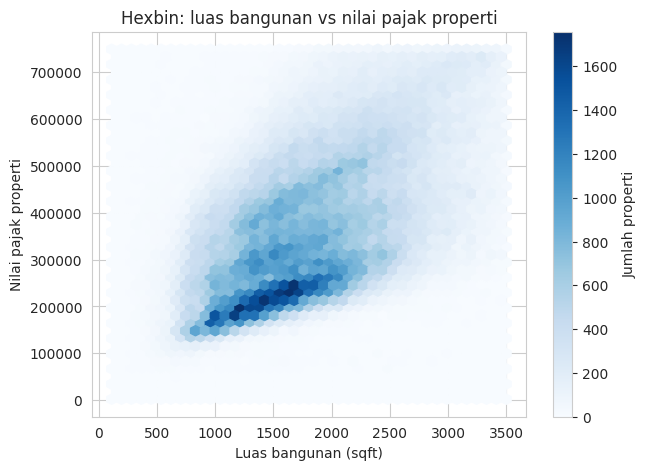

In [23]:
fig, ax = plt.subplots(figsize=(7, 5))
hb = ax.hexbin(kc_tax0["SqFtTotLiving"], kc_tax0["TaxAssessedValue"], gridsize=40, cmap="Blues")
ax.set_xlabel("Luas bangunan (sqft)")
ax.set_ylabel("Nilai pajak properti")
ax.set_title("Hexbin: luas bangunan vs nilai pajak properti")
fig.colorbar(hb, ax=ax, label="Jumlah properti")
plt.show()

Kalau titik-titik ini digambar sebagai scatterplot biasa, hampir 400 ribu titik akan saling menumpuk jadi satu gumpalan gelap dan susah dibaca. Hexbin menyelesaikan itu dengan mewarnai tiap sel heksagonal berdasarkan berapa banyak data di dalamnya, jadi pola kepadatan tetap terlihat.

In [24]:
lc_loans = pd.read_csv(BASE + "lc_loans.csv")

contingency = pd.crosstab(lc_loans["grade"], lc_loans["status"])
contingency

status,Charged Off,Current,Fully Paid,Late
grade,,,,
A,1562,50051,20408,469
B,5302,93852,31160,2056
C,6023,88928,23147,2777
D,5007,53281,13681,2308
E,2842,24639,5949,1374
F,1526,8444,2328,606
G,409,1990,643,199


In [25]:
# Ubah ke proporsi per baris (per grade), sesuai Tabel 1-8 di buku
contingency_prop = contingency.div(contingency.sum(axis=1), axis=0)
contingency_prop.round(3)

status,Charged Off,Current,Fully Paid,Late
grade,,,,
A,0.022,0.690,0.282,0.006
B,0.040,0.709,0.235,0.016
C,0.050,0.736,0.191,0.023
D,0.067,0.717,0.184,0.031
E,0.082,0.708,0.171,0.039
F,0.118,0.654,0.180,0.047
G,0.126,0.614,0.198,0.061


Terlihat pola yang cukup jelas: makin rendah grade pinjaman (mendekati G), makin besar proporsi yang berstatus *Charged Off* (gagal bayar) dibanding *Fully Paid* atau *Current*. Ini contoh bagus bagaimana contingency table membantu melihat hubungan antar dua variabel kategorikal.

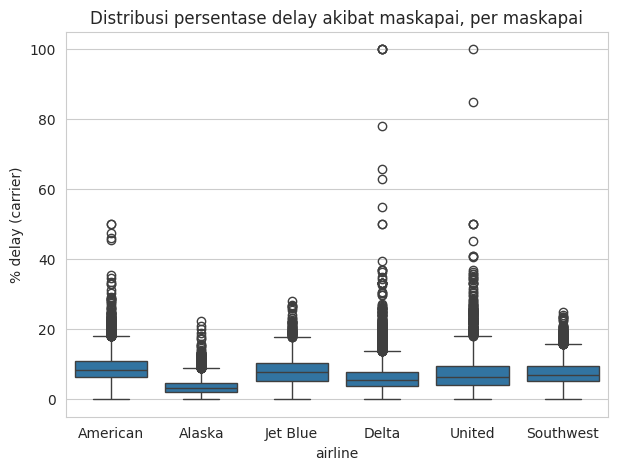

In [26]:
airline_stats = pd.read_csv(BASE + "airline_stats.csv")

fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=airline_stats, x="airline", y="pct_carrier_delay", ax=ax)
ax.set_title("Distribusi persentase delay akibat maskapai, per maskapai")
ax.set_ylabel("% delay (carrier)")
plt.show()

Boxplot ini membandingkan distribusi persentase delay yang disebabkan maskapai itu sendiri (bukan cuaca atau ATC), dipecah per maskapai. Alaska terlihat punya median dan sebaran paling kecil, sementara beberapa maskapai lain punya ekor lebih panjang, menandakan lebih sering ada delay parah akibat masalah internal maskapai.

## Poin-poin Penting Bab 1

- Kenali dulu jenis tiap kolom (numerik/kategorikal, kontinu/diskrit) sebelum memilih metode analisis.
- Mean gampang dihitung tapi rapuh terhadap outlier; median dan trimmed mean lebih tahan, seperti terlihat pada data populasi negara bagian.
- Weighted mean dan weighted median penting kalau tiap observasi tidak seharusnya punya bobot yang sama, seperti murder rate yang perlu ditimbang dengan populasi.
- Simpangan baku juga rapuh terhadap outlier karena melibatkan kuadrat; MAD dan IQR jadi alternatif yang lebih robust.
- Boxplot, histogram, dan density plot sama-sama menggambarkan bentuk distribusi, tapi paling informatif kalau dilihat bersamaan.
- Korelasi Pearson hanya menangkap hubungan linear, jadi selalu cek scatterplot-nya juga.
- Untuk data yang sangat banyak, hexbin plot jadi solusi supaya scatterplot tidak menumpuk jadi satu gumpalan gelap.
- Jenis kombinasi variabel (numerik-numerik, kategorikal-kategorikal, campuran) menentukan visualisasi paling cocok: hexbin, contingency table, atau boxplot berdampingan.

Referensi: Bruce, P., Bruce, A., & Gedeck, P. (2020). *Practical Statistics for Data Scientists*, 2nd Edition, Bab 1 "Exploratory Data Analysis". O'Reilly Media. Dataset: repo data resmi buku di GitHub (gedeck/practical-statistics-for-data-scientists).